Load Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\raksh\Downloads\universal_ml_training_dataset.csv")
df.head()

,age,income,months_at_company,num_products,web_visits,app_usage_hours,region,interaction_income_products,log_income,behavior_1,behavior_2,behavior_3,target_churn_binary,target_segment_multiclass,target_spend_regression,target_anomaly_binary
0,56,48353.457443,96,2,13,2.019921,South,96706.914886,10.786293,5.343111,-12.993693,12.601281,0,1,40777.906228,0
1,69,57462.278860,220,0,4,2.453852,West,0.000000,10.958884,2.443684,-15.232970,25.169021,0,2,45946.287898,0
2,46,44219.250087,176,1,12,2.592269,West,44219.250087,10.696915,7.019656,-11.215066,20.687126,0,1,32300.817620,0
3,32,56306.787159,39,1,6,0.528393,West,56306.787159,10.938570,4.390834,-20.266258,2.203419,0,2,41974.688288,0
4,60,37034.133936,168,1,9,0.480598,North,37034.133936,10.519595,5.461986,-6.614109,16.761772,0,0,24404.472339,0


Remove Unnecessary Targets

In [3]:
df = df.drop([
    "target_segment_multiclass",
    "target_spend_regression",
    "target_anomaly_binary"
], axis=1)

print("New Shape:", df.shape)

New Shape: (5000, 13)


Data Types

In [4]:
df.dtypes

age                              int64
income                         float64
months_at_company                int64
num_products                     int64
web_visits                       int64
app_usage_hours                float64
region                          object
interaction_income_products    float64
log_income                     float64
behavior_1                     float64
behavior_2                     float64
behavior_3                     float64
target_churn_binary              int64
dtype: object

Missing Values

In [5]:
df.isnull().sum()

age                            0
income                         0
months_at_company              0
num_products                   0
web_visits                     0
app_usage_hours                0
region                         0
interaction_income_products    0
log_income                     0
behavior_1                     0
behavior_2                     0
behavior_3                     0
target_churn_binary            0
dtype: int64

EDA (Exploratory Data Analysis)

Churn Distribution

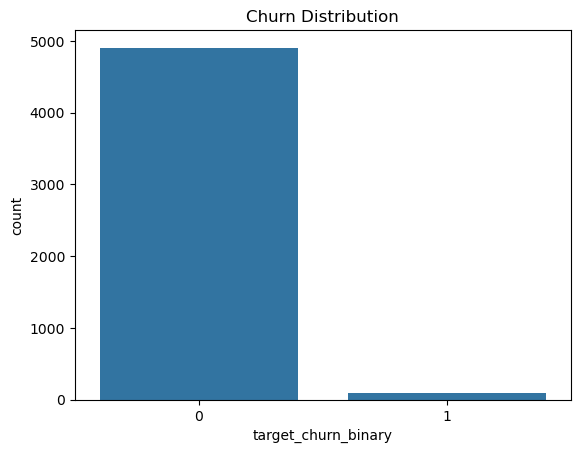

target_churn_binary
0    0.981
1    0.019
Name: proportion, dtype: float64


In [6]:
sns.countplot(x="target_churn_binary", data=df)
plt.title("Churn Distribution")
plt.show()

print(df["target_churn_binary"].value_counts(normalize=True))

Observation:
Churn rate ≈ 1.9% → Highly imbalanced dataset.

Correlation with Churn

In [7]:
corr = df.corr(numeric_only=True)["target_churn_binary"].sort_values(ascending=False)
print(corr)

target_churn_binary            1.000000
num_products                   0.065672
behavior_2                     0.065026
age                            0.061814
interaction_income_products    0.036227
app_usage_hours               -0.015335
web_visits                    -0.024873
behavior_1                    -0.027724
income                        -0.045111
log_income                    -0.072504
behavior_3                    -0.073331
months_at_company             -0.082054
Name: target_churn_binary, dtype: float64


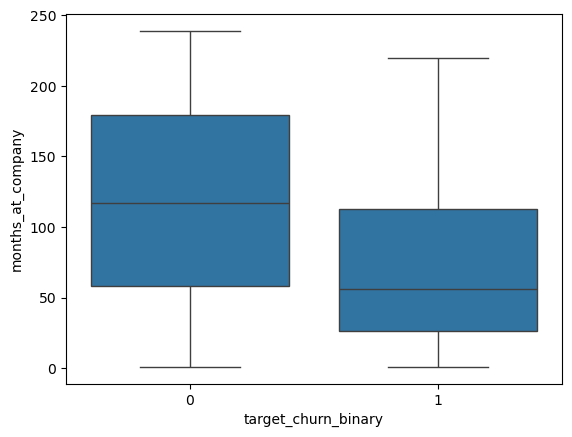

In [8]:
sns.boxplot(x="target_churn_binary", y="months_at_company", data=df)
plt.show()

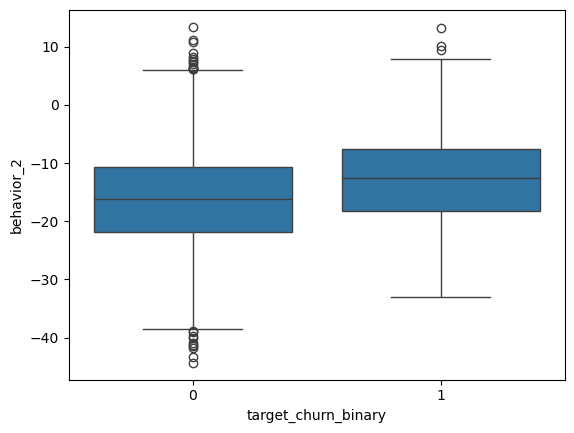

In [9]:
sns.boxplot(x="target_churn_binary", y="behavior_2", data=df)
plt.show()

Baseline Model (Logistic Regression)

In [10]:
#Prepare Data
y = df["target_churn_binary"]
X = df.drop("target_churn_binary", axis=1)

In [11]:
# Encode Region
X = pd.get_dummies(X, columns=["region"], drop_first=True)

In [12]:
# Train
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.99      0.71      0.83       981
           1       0.04      0.63      0.08        19

    accuracy                           0.71      1000
   macro avg       0.52      0.67      0.45      1000
weighted avg       0.97      0.71      0.81      1000

[[696 285]
 [  7  12]]


Result:
Improved recall for churn class (~63%).

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       981
           1       0.00      0.00      0.00        19

    accuracy                           0.98      1000
   macro avg       0.49      0.50      0.50      1000
weighted avg       0.96      0.98      0.97      1000

[[981   0]
 [ 19   0]]


C:\Users\raksh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\raksh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\raksh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Observation:
Model predicts majority class → 0 recall for churn.

In [16]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

rf_model_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model_smote.fit(X_train_resampled, y_train_resampled)

y_pred_rf_smote = rf_model_smote.predict(X_test)

print("Random Forest + SMOTE Results")
print(classification_report(y_test, y_pred_rf_smote))
print(confusion_matrix(y_test, y_pred_rf_smote))

Random Forest + SMOTE Results
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       981
           1       0.05      0.05      0.05        19

    accuracy                           0.96      1000
   macro avg       0.52      0.52      0.52      1000
weighted avg       0.96      0.96      0.96      1000

[[963  18]
 [ 18   1]]


Observation:
Minor improvement but still weak churn detection.

In [17]:
y_probs = log_model.predict_proba(X_test_scaled)[:, 1]

# Custom threshold
threshold = 0.5
y_pred_custom = (y_probs > threshold).astype(int)

print("Custom Threshold Results (0.4)")
print(classification_report(y_test, y_pred_custom))
print(confusion_matrix(y_test, y_pred_custom))

Custom Threshold Results (0.4)
              precision    recall  f1-score   support

           0       0.99      0.71      0.83       981
           1       0.04      0.63      0.08        19

    accuracy                           0.71      1000
   macro avg       0.52      0.67      0.45      1000
weighted avg       0.97      0.71      0.81      1000

[[696 285]
 [  7  12]]


In [18]:
y_probs = log_model.predict_proba(X_test_scaled)[:, 1]

# Custom threshold
threshold = 0.4
y_pred_custom = (y_probs > threshold).astype(int)

print("Custom Threshold Results (0.4)")
print(classification_report(y_test, y_pred_custom))
print(confusion_matrix(y_test, y_pred_custom))

Custom Threshold Results (0.4)
              precision    recall  f1-score   support

           0       0.99      0.59      0.74       981
           1       0.03      0.68      0.06        19

    accuracy                           0.59      1000
   macro avg       0.51      0.64      0.40      1000
weighted avg       0.97      0.59      0.72      1000

[[576 405]
 [  6  13]]


Observation:
Lower threshold increases recall but increases false positives.

This demonstrates Precision–Recall tradeoff.

In [19]:
y_probs = log_model.predict_proba(X_test_scaled)[:, 1]

# Custom threshold
threshold = 0.3
y_pred_custom = (y_probs > threshold).astype(int)

print("Custom Threshold Results (0.4)")
print(classification_report(y_test, y_pred_custom))
print(confusion_matrix(y_test, y_pred_custom))

Custom Threshold Results (0.4)
              precision    recall  f1-score   support

           0       0.99      0.45      0.62       981
           1       0.03      0.74      0.05        19

    accuracy                           0.46      1000
   macro avg       0.51      0.59      0.33      1000
weighted avg       0.97      0.46      0.61      1000

[[442 539]
 [  5  14]]


In [20]:
results = pd.DataFrame({
    "probability": y_probs,
    "actual": y_test.values
})

top_50 = results.sort_values("probability", ascending=False).head(50)

print("Actual churners in top 50:")
print(top_50["actual"].sum())

Actual churners in top 50:
2


Business Insight:
Only 2 churners in top 50 → weak risk concentration.

In [21]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": log_model.coef_[0]
})

feature_importance["abs_coeff"] = feature_importance["coefficient"].abs()

feature_importance.sort_values("abs_coeff", ascending=False).head(10)

,feature,coefficient,abs_coeff
2,months_at_company,-1.164419,1.164419
9,behavior_2,0.820886,0.820886
6,interaction_income_products,0.786603,0.786603
10,behavior_3,0.367157,0.367157
13,region_West,0.228158,0.228158
4,web_visits,-0.155525,0.155525
7,log_income,-0.119318,0.119318
11,region_North,-0.117660,0.117660
12,region_South,0.091705,0.091705
3,num_products,-0.057366,0.057366
